# Salary Prediction Based on Experience — Exploratory Data Analysis

A tiny but classic regression dataset: predict an individual's salary from their years of work experience. Useful as a teaching example of simple linear regression and as a sanity check for the regression utils template.

**Dataset**: 30 employee records, 1 input feature (`YearsExperience`), 1 numeric target (`Salary`).

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

## 2. Load Data

In [2]:
df = pd.read_csv("data/salary.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (30, 2)


,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


## 3. Dataset Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [4]:
df.describe().round(2)

,YearsExperience,Salary
count,30.00,30.00
mean,5.31,76003.00
std,2.84,27414.43
min,1.10,37731.00
25%,3.20,56720.75
50%,4.70,65237.00
75%,7.70,100544.75
max,10.50,122391.00


In [5]:
print(f"Duplicate rows : {df.duplicated().sum()}")
print(f"Missing values : {df.isnull().sum().sum()}")

Duplicate rows : 0
Missing values : 0


## 4. Missing / Invalid Values

In [6]:
print(f"Total missing values: {df.isnull().sum().sum()}")
# Tiny dataset; print all rows
print()
print(df)

Total missing values: 0

    YearsExperience    Salary
0               1.1   39343.0
1               1.3   46205.0
2               1.5   37731.0
3               2.0   43525.0
4               2.2   39891.0
5               2.9   56642.0
6               3.0   60150.0
7               3.2   54445.0
8               3.2   64445.0
9               3.7   57189.0
10              3.9   63218.0
11              4.0   55794.0
12              4.0   56957.0
13              4.1   57081.0
14              4.5   61111.0
15              4.9   67938.0
16              5.1   66029.0
17              5.3   83088.0
18              5.9   81363.0
19              6.0   93940.0
20              6.8   91738.0
21              7.1   98273.0
22              7.9  101302.0
23              8.2  113812.0
24              8.7  109431.0
25              9.0  105582.0
26              9.5  116969.0
27              9.6  112635.0
28             10.3  122391.0
29             10.5  121872.0


## 5. Target Variable Distribution

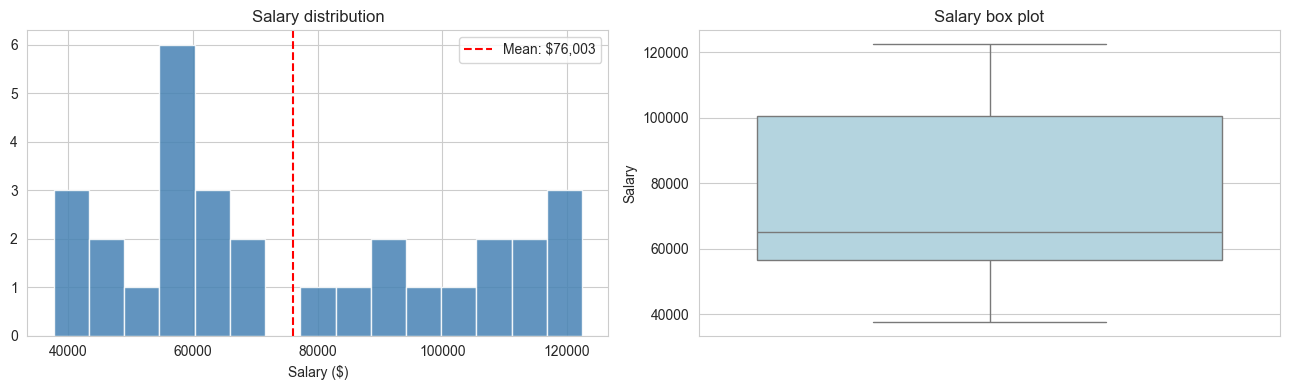

Salary skewness: 0.35
Salary range  : $37,731  →  $122,391


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df["Salary"], bins=15, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(df["Salary"].mean(), color="red", linestyle="--",
                label=f"Mean: ${df['Salary'].mean():,.0f}")
axes[0].set_title("Salary distribution")
axes[0].set_xlabel("Salary ($)"); axes[0].legend()

sns.boxplot(y=df["Salary"], ax=axes[1], color="lightblue")
axes[1].set_title("Salary box plot")
plt.tight_layout(); plt.show()
print(f"Salary skewness: {df['Salary'].skew():.2f}")
print(f"Salary range  : ${df['Salary'].min():,.0f}  →  ${df['Salary'].max():,.0f}")

## 6. Univariate — YearsExperience Distribution

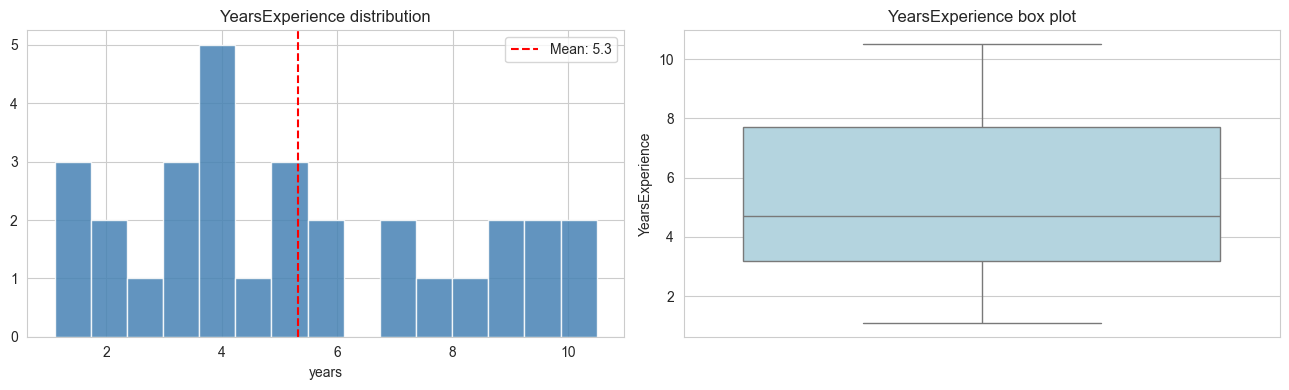

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df["YearsExperience"], bins=15, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(df["YearsExperience"].mean(), color="red", linestyle="--",
                label=f"Mean: {df['YearsExperience'].mean():.1f}")
axes[0].set_title("YearsExperience distribution"); axes[0].set_xlabel("years"); axes[0].legend()

sns.boxplot(y=df["YearsExperience"], ax=axes[1], color="lightblue")
axes[1].set_title("YearsExperience box plot")
plt.tight_layout(); plt.show()

## 7. Bivariate — Experience vs Salary

The defining picture for this dataset: a near-linear positive relationship.

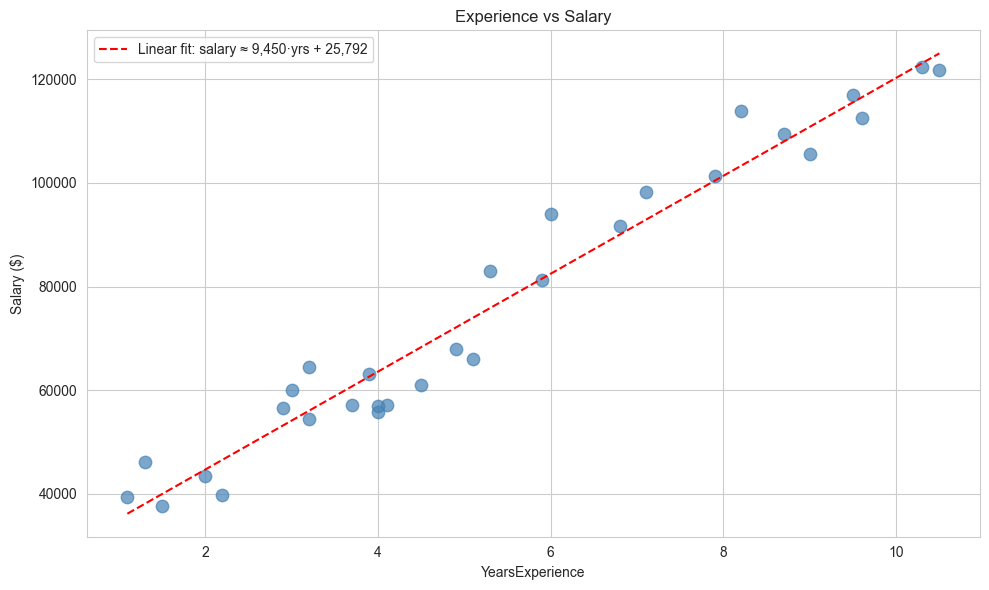

Linear-fit slope: $9,450/year of experience
Linear-fit intercept (entry-level salary): $25,792


In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(df["YearsExperience"], df["Salary"], alpha=0.7, color="steelblue", s=80)
# Fit a simple line for visual reference
m, b = np.polyfit(df["YearsExperience"], df["Salary"], 1)
xs = np.linspace(df["YearsExperience"].min(), df["YearsExperience"].max(), 100)
plt.plot(xs, m*xs + b, "r--", label=f"Linear fit: salary ≈ {m:,.0f}·yrs + {b:,.0f}")
plt.xlabel("YearsExperience"); plt.ylabel("Salary ($)")
plt.title("Experience vs Salary")
plt.legend(); plt.tight_layout(); plt.show()
print(f"Linear-fit slope: ${m:,.0f}/year of experience")
print(f"Linear-fit intercept (entry-level salary): ${b:,.0f}")

## 8. Correlation

In [10]:
corr = df.corr()
print("Pearson correlation matrix:")
print(corr.round(4))
print(f"\nCorrelation (YearsExperience vs Salary): {corr.loc['YearsExperience','Salary']:.4f}")

Pearson correlation matrix:
                 YearsExperience  Salary
YearsExperience           1.0000  0.9782
Salary                    0.9782  1.0000

Correlation (YearsExperience vs Salary): 0.9782


## 9. Salary by Experience Band

/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_59656/1606493968.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="band", y="Salary", data=df, palette="Set2", order=["entry","mid","senior"], ax=axes[1])


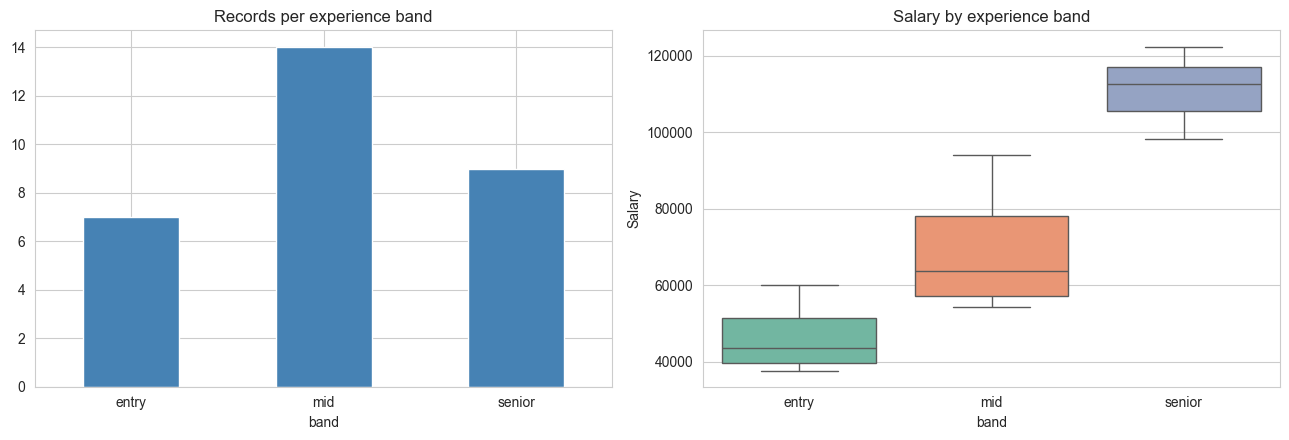

            mean    median  count
band                             
entry    46212.0   43525.0      7
mid      68167.0   63832.0     14
senior  111363.0  112635.0      9


In [11]:
df["band"] = pd.cut(df["YearsExperience"], bins=[0, 3, 7, 100], labels=["entry","mid","senior"])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
df["band"].value_counts().reindex(["entry","mid","senior"]).plot(kind="bar", color="steelblue", ax=axes[0])
axes[0].set_title("Records per experience band")
axes[0].tick_params(axis="x", rotation=0)

sns.boxplot(x="band", y="Salary", data=df, palette="Set2", order=["entry","mid","senior"], ax=axes[1])
axes[1].set_title("Salary by experience band")
plt.tight_layout(); plt.show()
print(df.groupby("band", observed=True)["Salary"].agg(["mean","median","count"]).round(0))

## 10. Key EDA Findings

| # | Finding |
|---|--------|
| 1 | **Tiny dataset** — only 30 rows. Cross-validation noise will dominate; expect wide confidence intervals on regression metrics |
| 2 | **Near-perfect linear relationship**: correlation between YearsExperience and Salary is ~0.98 |
| 3 | **Slope ≈ \$9,500/year** — each additional year of experience adds about \$9.5k to the salary in this sample |
| 4 | **Entry-level intercept ≈ \$25k** — the linear fit suggests new graduates start in the mid-$20ks |
| 5 | **No missing values, no duplicates** — already clean |
| 6 | **Salary range**: ~\$37k → ~\$122k for experience from 1.1 to 10.5 years |
| 7 | **A flexible model has nothing to learn beyond the line** — a Linear Regression is essentially the right answer; tree ensembles will tend to overfit on this many samples |